# Briefer-than-brief stimuli: frequency and phase

In [2]:
import btb
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.special import factorial
from scipy.ndimage import gaussian_filter1d

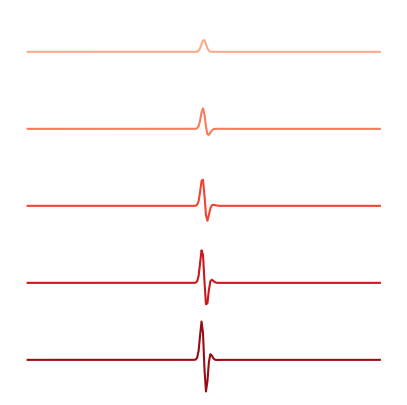

In [3]:
n = 5
colors = plt.cm.Reds(np.linspace(0.3, 0.9, n))
speedups = np.linspace(1, 3, n)
fig, ax = plt.subplots(n, 1, sharey=True, figsize=(5,5))
fig.subplots_adjust(hspace=0.)

isi = 0
vir_tau = 0.005
nu = 2
frame_rate = 1000
times = btb.generate_times(stim_dur=0.5)
stim = btb.generate_stim(times, isi=isi, pulse_duration=1)

for i in range(len(speedups)):
    stim_btb, scaling_factor = btb.generate_btb(stim, times,
                                            vir_tau=vir_tau, speedup=speedups[i])
    ax[i].plot(times-0.15, stim_btb, color=colors[i])
    ax[i].axis('off')
    #ax[i].set_title('speedup = {}'.format(speedups[i]), loc='left')

fig.savefig('parametric_modulation.png', dpi=600)

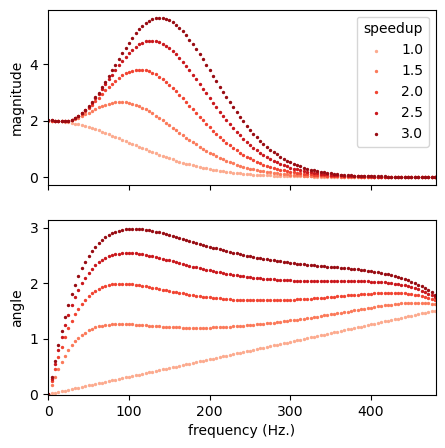

In [4]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(5,5))
times = btb.generate_times(stim_dur=1)

for i in range(len(speedups)):
    speedup = speedups[i]
    vir = btb.adelson_bergen_vir(times, tau = vir_tau, n=2, nu=nu) / frame_rate
    vir = np.roll(vir, int(len(times)/2))
    vir_f = fft(vir)
    
    # sped up VIR
    vir_prime = btb.adelson_bergen_vir(times, tau = vir_tau/speedup, n=2, nu=nu) / frame_rate
    vir_prime = np.roll(vir_prime, int(len(times)/2))
    
    # estimated sped up response
    stim_prime = np.convolve(stim, vir_prime, mode='same') 
    stim_prime_f = fft(stim_prime)
    
    stim_db = ifft(stim_prime_f / vir_f).real
    stim_db = np.roll(stim_db, int(len(times)/2)-1)

    ax[0].scatter(np.fft.fftfreq(len(stim_db), d=0.001)[0::2], # only take sin
               abs(fft(stim_db))[0::2], color=colors[i], s=2, label='{}'.format(speedup))
    ax[0].set_ylabel('magnitude')
    ax[0].legend(title='speedup')
    
    ax[0].set_xlim([0, len(times)])
    ax[1].set_xlim([0, len(times)])
    
    ax[1].scatter(np.fft.fftfreq(len(stim_db), d=0.001)[0::2], # only take sin
               np.angle(fft(stim_db))[0::2], color=colors[i], s=2)
    ax[1].set_ylabel('angle')
    ax[1].set_ylim([-0.01, np.pi])

    ax[1].set_xlabel('frequency (Hz.)')

fig.savefig('parametric_modulation_frequency_phase.png', dpi=600)